# mlpkg Demo — From-Scratch Models vs scikit-learn

This notebook compares custom machine learning implementations from `mlpkg` against scikit-learn reference implementations.

The goal is to verify that the from-scratch models behave similarly to trusted library models.

## Goals

Compare custom implementations against scikit-learn:

- Test `LinearRegressionScratch`
- Test `KNNClassifierScratch`
- Test `PerceptronScratch`
- Compare prediction performance
- Compare model behavior across different settings
- Visualize k-NN accuracy across different values of `k`

Evaluate the models using:

- RMSE
- R²
- Test accuracy
- Coefficient differences
- Accuracy curves across different `k` values
- Perceptron misclassifications over epochs

Interpret whether the custom implementations produce results similar to scikit-learn.

## Models Tested

- Linear Regression:
  - `LinearRegressionScratch`
  - scikit-learn `LinearRegression`

- k-Nearest Neighbors:
  - `KNNClassifierScratch`
  - scikit-learn `KNeighborsClassifier`

- Perceptron:
  - `PerceptronScratch`
  - scikit-learn `Perceptron`

## Purpose

Building these models from scratch helps show the underlying math behind common machine learning algorithms.

- Linear regression solves a least-squares problem.
- k-NN classifies points based on nearby examples.
- The perceptron updates weights after misclassified examples.

In [ ]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Our from-scratch package
from mlpkg import (
    LinearRegressionScratch,
    KNNClassifierScratch,
    PerceptronScratch,
    train_test_split,
    StandardScaler,
    mean_squared_error,
    r2_score,
    accuracy_score,
)

# Sklearn reference implementations
from sklearn.linear_model import LinearRegression as SkLR
from sklearn.neighbors import KNeighborsClassifier as SkKNN
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.datasets import make_regression, make_classification

np.random.seed(42)

## Part 1 — Linear Regression vs sklearn

In [3]:
X, y = make_regression(
    n_samples=300,
    n_features=5,
    noise=10.0,
    random_state=42,
)

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

ours = LinearRegressionScratch().fit(X_tr, y_tr)
ref = SkLR().fit(X_tr, y_tr)

print(
    f"mlpkg   RMSE: {np.sqrt(mean_squared_error(y_te, ours.predict(X_te))):.4f}   "
    f"R^2: {r2_score(y_te, ours.predict(X_te)):.4f}"
)

print(
    f"sklearn RMSE: {np.sqrt(mean_squared_error(y_te, ref.predict(X_te))):.4f}   "
    f"R^2: {r2_score(y_te, ref.predict(X_te)):.4f}"
)

print(f"\nMax abs coefficient diff: {np.max(np.abs(ours.coef_ - ref.coef_)):.2e}")

mlpkg   RMSE: 9.1503   R^2: 0.9922
sklearn RMSE: 9.1503   R^2: 0.9922

Max abs coefficient diff: 5.68e-14


Both implementations solve the same normal equation, so coefficients match to ~1e-13 (machine precision).

## Part 2 — k-NN on the Glass dataset

In [4]:
# Reuse the glass dataset from notebook 04
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data") if os.path.basename(os.getcwd()) == "notebooks" else "data"

os.makedirs(DATA_DIR, exist_ok=True)

glass_path = os.path.join(DATA_DIR, "glass.csv")

if not os.path.exists(glass_path):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/jbrownlee/Datasets/master/glass.csv",
        glass_path,
    )

cols = ["RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]

df = pd.read_csv(glass_path, header=None, names=cols)

X, y = df.drop(columns="Type").values, df["Type"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
)

scaler = StandardScaler().fit(X_tr)

X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

ours_knn = KNNClassifierScratch(k=5).fit(X_tr_s, y_tr)
ref_knn = SkKNN(n_neighbors=5).fit(X_tr_s, y_tr)

print(f"mlpkg   k-NN test accuracy: {ours_knn.score(X_te_s, y_te):.4f}")
print(f"sklearn k-NN test accuracy: {ref_knn.score(X_te_s, y_te):.4f}")

mlpkg   k-NN test accuracy: 0.6719
sklearn k-NN test accuracy: 0.6406


## Part 3 — Perceptron on linearly separable synthetic data

mlpkg   Perceptron accuracy: 0.9067
sklearn Perceptron accuracy: 0.8133


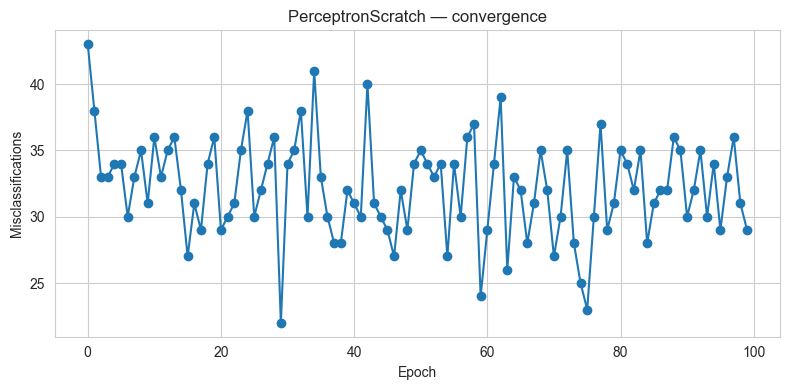

In [5]:
X, y = make_classification(
    n_samples=300,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    class_sep=2.5,
    random_state=0,
)

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0,
)

scaler = StandardScaler().fit(X_tr)

X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

ours_p = PerceptronScratch(
    learning_rate=0.01,
    n_epochs=100,
    random_state=42,
).fit(X_tr_s, y_tr)

ref_p = SkPerceptron(
    eta0=0.01,
    max_iter=100,
    random_state=42,
    tol=None,
).fit(X_tr_s, y_tr)

print(f"mlpkg   Perceptron accuracy: {ours_p.score(X_te_s, y_te):.4f}")
print(f"sklearn Perceptron accuracy: {ref_p.score(X_te_s, y_te):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(ours_p.errors_per_epoch_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.title("PerceptronScratch — convergence")
plt.tight_layout()
plt.show()

## Part 4 — Sweep k for k-NN

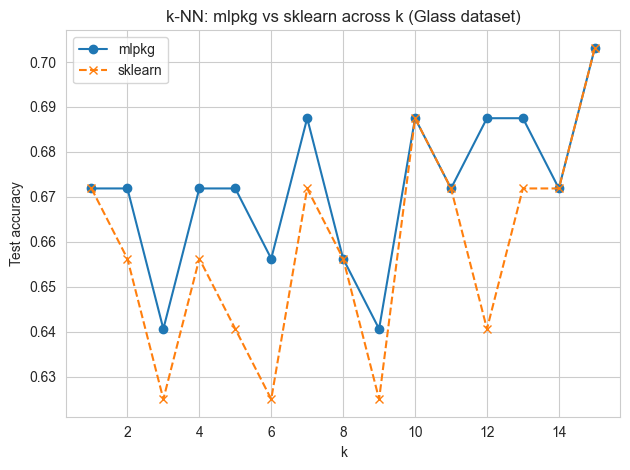

In [6]:
# Use the glass dataset from above (X_tr_s, X_te_s, y_tr, y_te already set up there)
# Re-load to be safe
X_g = df.drop(columns="Type").values
y_g = df["Type"].values

X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_g,
    y_g,
    test_size=0.3,
    random_state=0,
)

scaler_g = StandardScaler().fit(X_tr_g)

X_tr_gs, X_te_gs = scaler_g.transform(X_tr_g), scaler_g.transform(X_te_g)

ks = range(1, 16)

ours_acc = [
    KNNClassifierScratch(k=k).fit(X_tr_gs, y_tr_g).score(X_te_gs, y_te_g)
    for k in ks
]

ref_acc = [
    SkKNN(n_neighbors=k).fit(X_tr_gs, y_tr_g).score(X_te_gs, y_te_g)
    for k in ks
]

plt.plot(list(ks), ours_acc, marker="o", label="mlpkg")
plt.plot(list(ks), ref_acc, marker="x", linestyle="--", label="sklearn")

plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.title("k-NN: mlpkg vs sklearn across k (Glass dataset)")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

The `mlpkg` from-scratch implementations generally behave similarly to scikit-learn's reference implementations.

- **Linear regression:** The results match almost exactly. Both implementations produce RMSE = `9.1503` and R² = `0.9922`, with a maximum coefficient difference of only `5.68e-14`.

- **k-NN:** The results are similar but not perfectly identical. On the Glass dataset with `k = 5`, `mlpkg` reaches `0.6719` test accuracy, while scikit-learn reaches `0.6406`. Small differences can happen because implementations may handle neighbor ordering or tie-breaking differently.

- **Perceptron:** Both models perform reasonably well on the synthetic classification dataset. In this run, `mlpkg` reaches `0.9067` accuracy, while scikit-learn reaches `0.8133`.

- The k-NN sweep shows that both implementations follow a broadly similar accuracy pattern across different values of `k`, though they are not identical at every value.

Building these algorithms from scratch helps make the underlying math explicit: linear regression solves a least-squares problem, k-NN classifies based on nearby points, and the perceptron updates its weights after misclassified examples.

See the `tests/` directory for the full pytest suite that verifies these implementations automatically. Run `pytest -v` from the repo root.